LIST iMPORTANT LIBRARY

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Life Expectancy Data (1).csv to Life Expectancy Data (1).csv


LOAD DATA

In [ ]:
df = pd.read_csv('Life Expectancy Data (1).csv')

In [ ]:
df.head(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


In [ ]:
 df.shape

(2938, 22)

DATA CLEANING

In [ ]:
df.isnull().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


In [ ]:
for cols in df.columns:
    if df[cols].isnull().sum()>0:
        print(cols)

Life expectancy 
Adult Mortality
Alcohol
Hepatitis B
 BMI 
Polio
Total expenditure
Diphtheria 
GDP
Population
 thinness  1-19 years
 thinness 5-9 years
Income composition of resources
Schooling


In [ ]:
imputer = SimpleImputer(missing_values=np.nan, strategy='mean', fill_value=None)
for cols in df.columns:
    if df[cols].isnull().sum()>0:
        df[cols] =  imputer.fit_transform(df[[cols]])

CHECK OUTLIERS

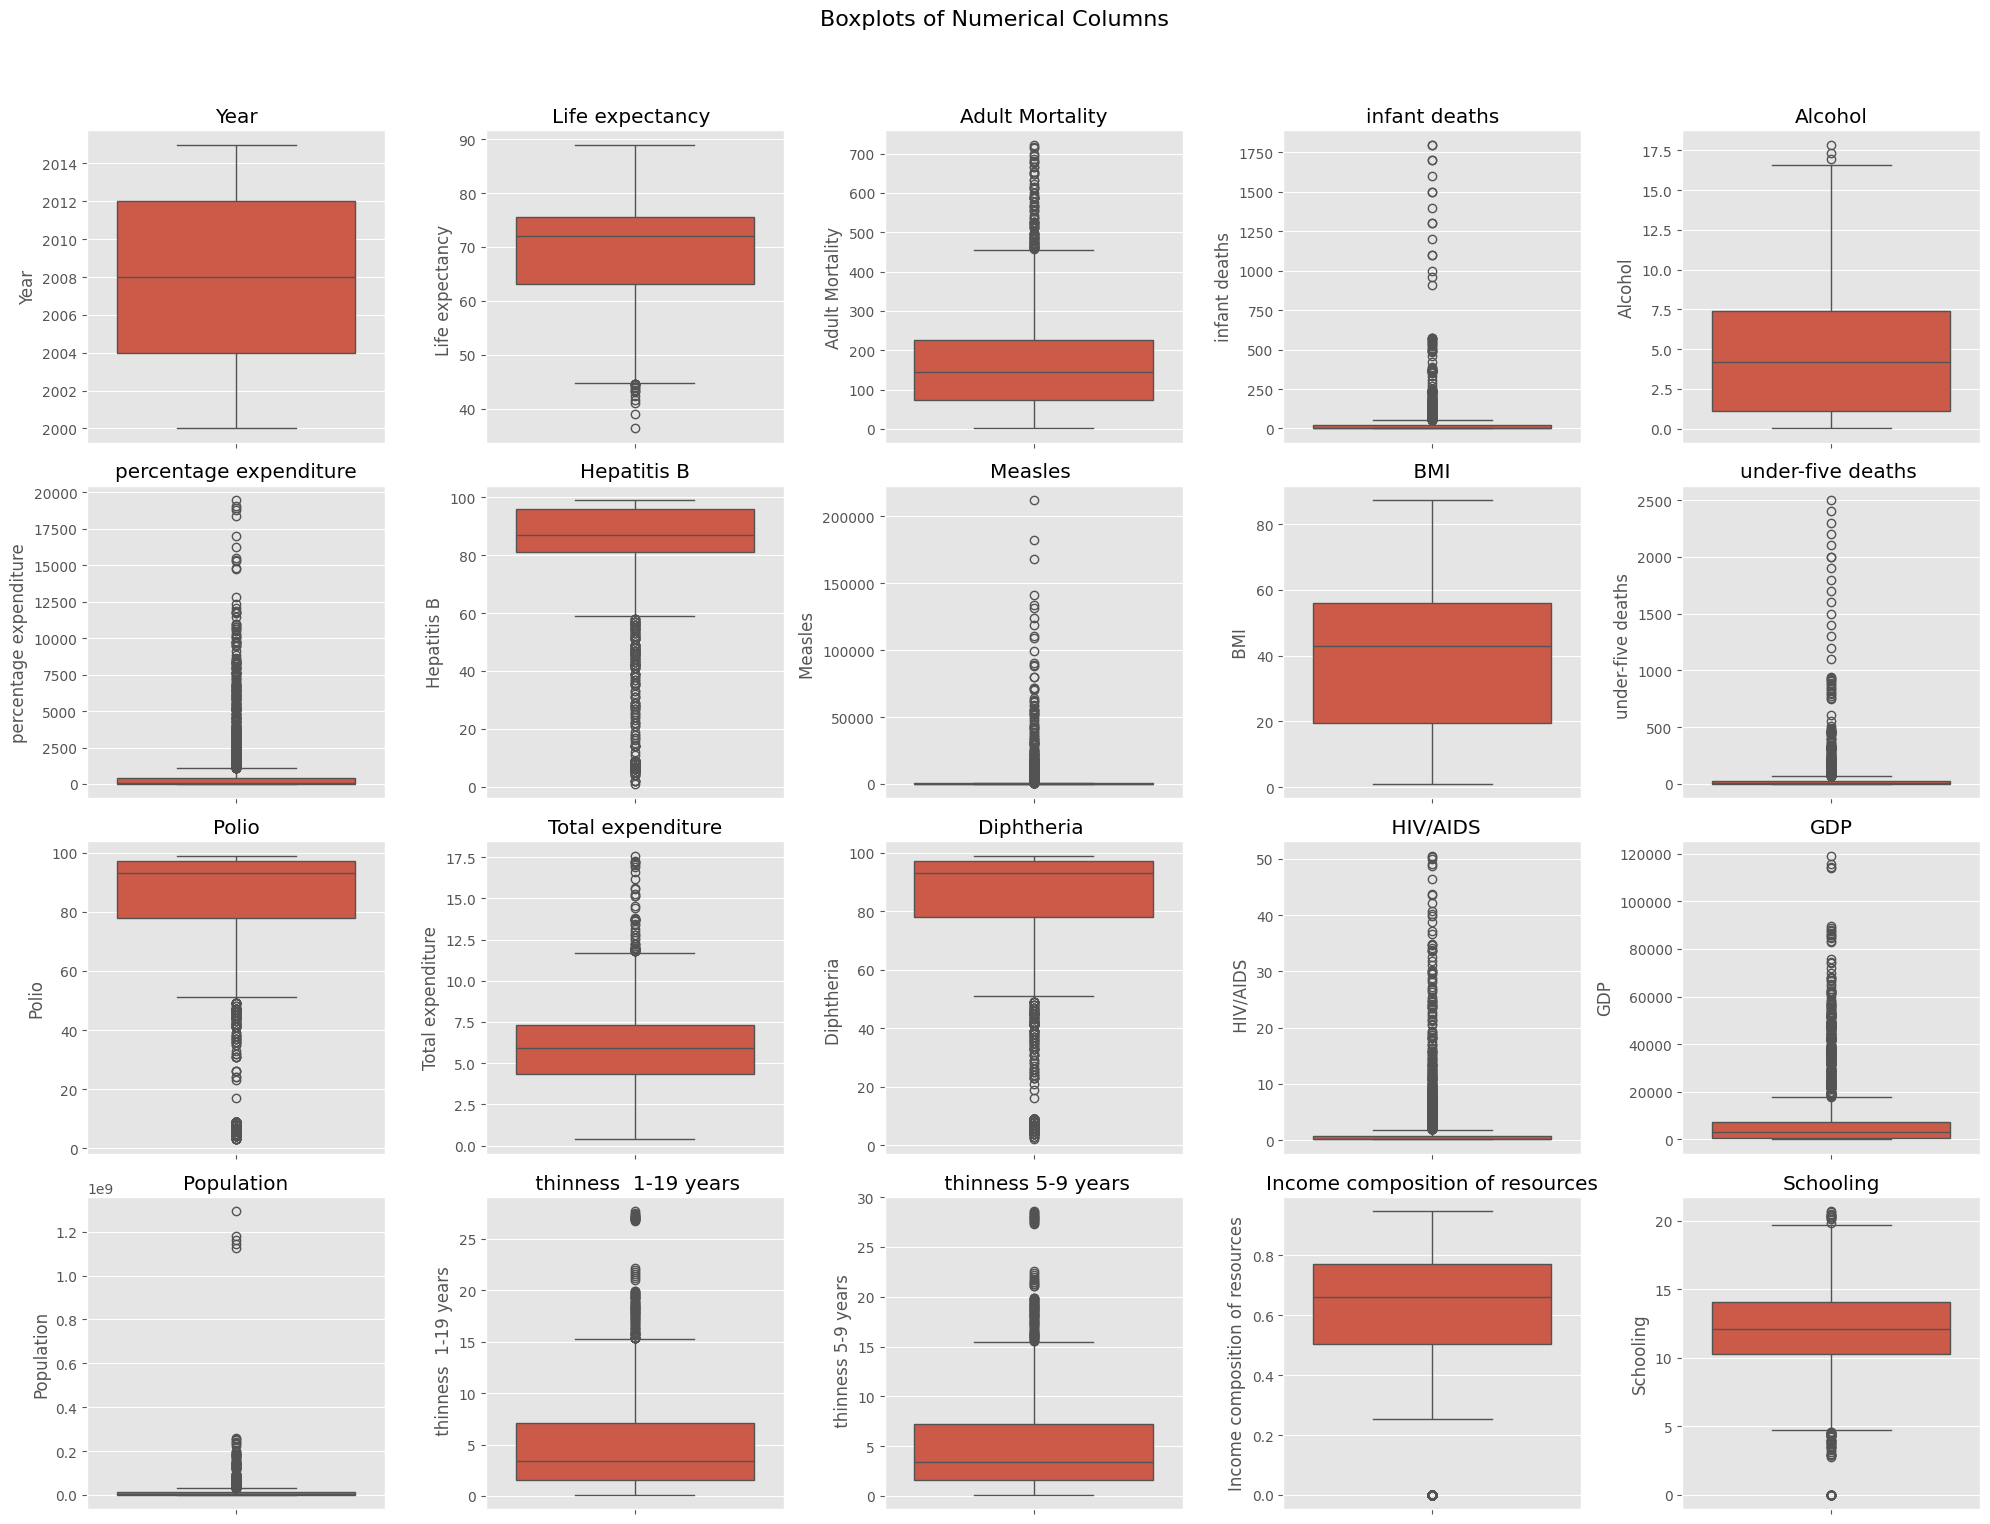

In [ ]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
fig.suptitle('Boxplots of Numerical Columns', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot boxplots for each numerical column
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# Remove any empty subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
df.shape

(2938, 22)

In [ ]:
# Specify the list of columns you want to handle outliers for
outlier_cols = [
    'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure',
    'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio',
    'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
    ' thinness  1-19 years', ' thinness 5-9 years',
    'Income composition of resources', 'Schooling'
]

# Perform outlier handling for each specified column
for col_name in outlier_cols:
    # Calculate quartiles and IQR
    q1 = df[col_name].quantile(0.25)
    q3 = df[col_name].quantile(0.75)
    iqr = q3 - q1

    # Define the lower and upper bounds for outliers
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Replace outliers with the mean value of the column
    df[col_name] = np.where((df[col_name] > upper_bound) | (df[col_name] < lower_bound),
                            np.mean(df[col_name]), df[col_name])

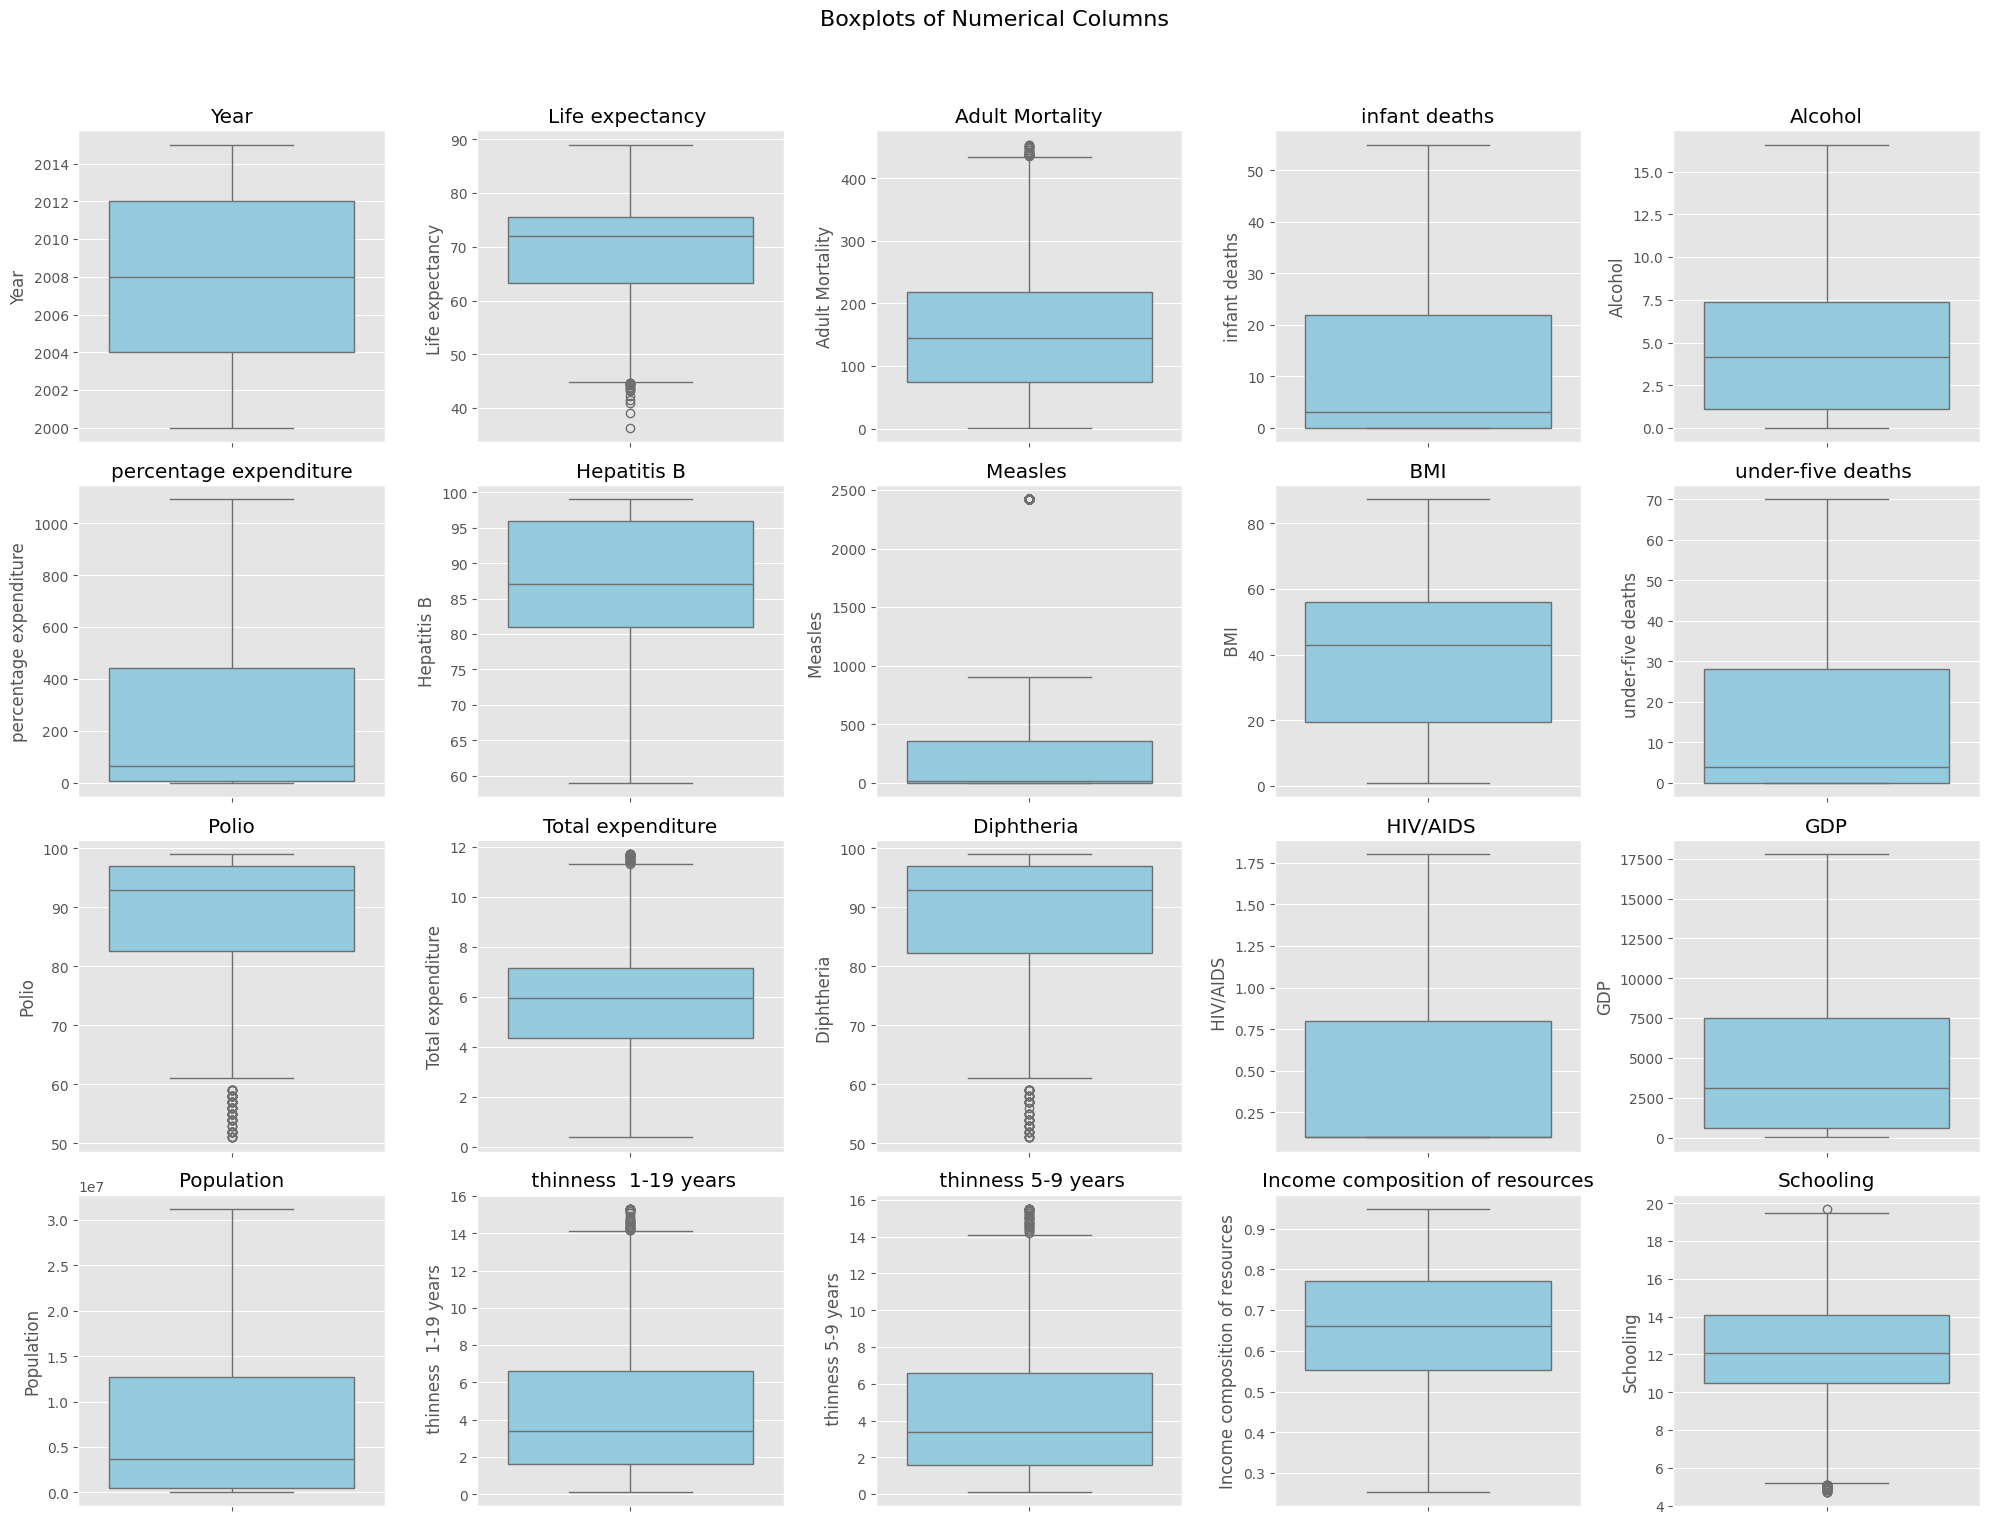

In [ ]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
fig.suptitle('Boxplots of Numerical Columns', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot boxplots for each numerical column
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

# Remove any empty subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

EXPLORE DATA ANALYS

In [ ]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,30.303948,0.01,71.279624,65.0,2419.59224,...,82.550188,8.16,65.0,0.1,584.259210,1.275338e+07,4.839704,4.870317,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,30.303948,0.01,73.523582,62.0,492.00000,...,58.000000,8.18,62.0,0.1,612.696514,3.275820e+05,4.839704,4.870317,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,30.303948,0.01,73.219243,64.0,430.00000,...,62.000000,8.13,64.0,0.1,631.744976,1.275338e+07,4.839704,4.870317,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,30.303948,0.01,78.184215,67.0,2419.59224,...,67.000000,8.52,67.0,0.1,669.959000,3.696958e+06,4.839704,4.870317,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,30.303948,0.01,7.097109,68.0,2419.59224,...,68.000000,7.87,68.0,0.1,63.537231,2.978599e+06,4.839704,4.870317,0.454,9.5


In [ ]:
df.Country.value_counts()

,count
Country,
Afghanistan,16
Albania,16
Algeria,16
Angola,16
Antigua and Barbuda,16
...,...
Monaco,1
Marshall Islands,1
Saint Kitts and Nevis,1


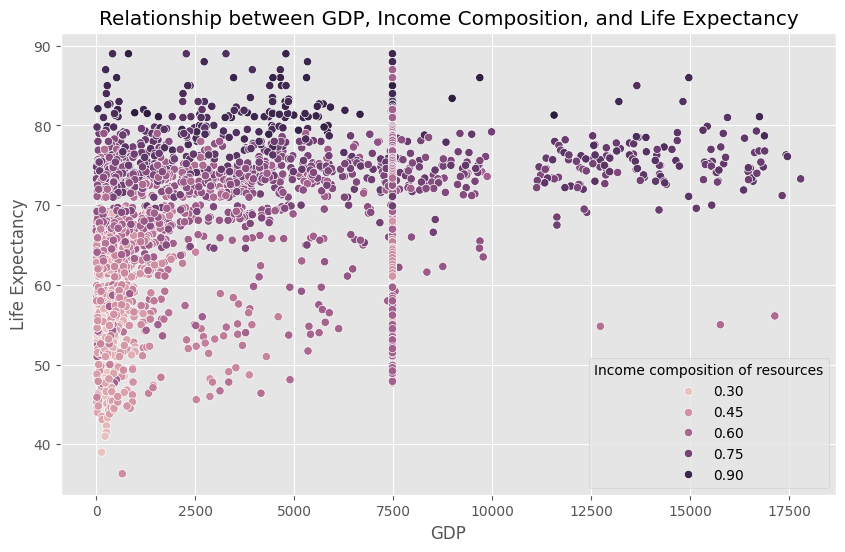

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GDP', y='Life expectancy ', hue='Income composition of resources', data=df)
plt.title('Relationship between GDP, Income Composition, and Life Expectancy')
plt.xlabel('GDP')
plt.ylabel('Life Expectancy')
plt.show()

fig = px.scatter_3d(df, x='GDP', y='Income composition of resources', z='Life expectancy ',
                    color='Income composition of resources',
                    title='Relationship between GDP, Income Composition, and Life Expectancy (3D)')
fig.show()


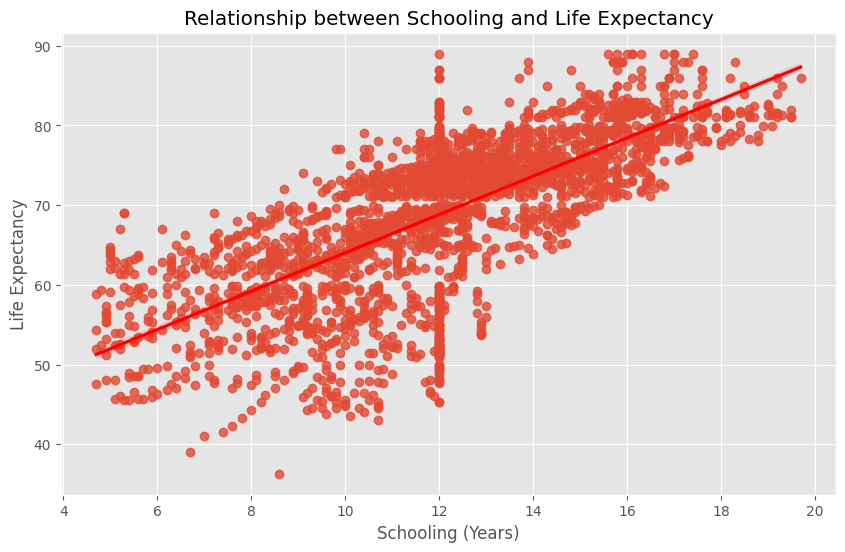

In [ ]:

plt.figure(figsize=(10, 6))
sns.regplot(x='Schooling', y='Life expectancy ', data=df, line_kws={'color': 'red'})
plt.title('Relationship between Schooling and Life Expectancy')
plt.xlabel('Schooling (Years)')
plt.ylabel('Life Expectancy')
plt.show()


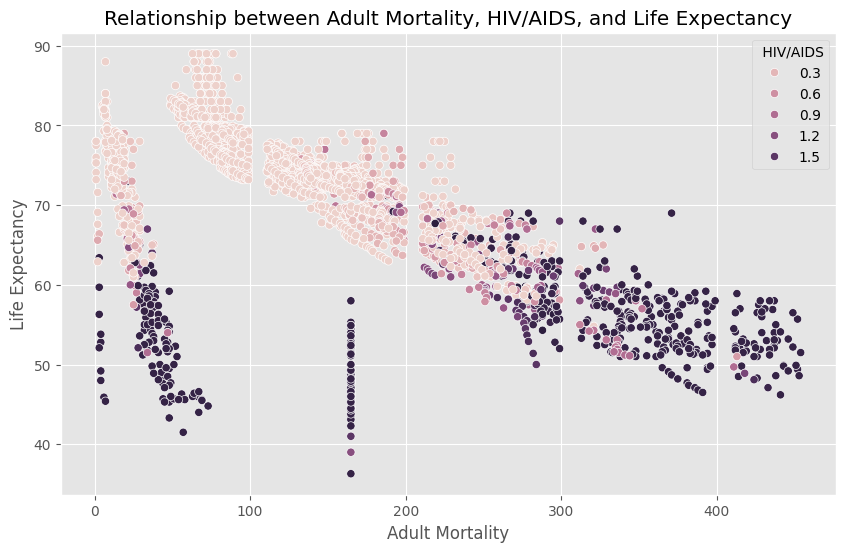

In [ ]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Adult Mortality', y='Life expectancy ', hue=' HIV/AIDS', data=df)
plt.title('Relationship between Adult Mortality, HIV/AIDS, and Life Expectancy')
plt.xlabel('Adult Mortality')
plt.ylabel('Life Expectancy')
plt.show()

fig = px.scatter_3d(df, x='Adult Mortality', y=' HIV/AIDS', z='Life expectancy ',
                    color=' HIV/AIDS',
                    title='Relationship between Adult Mortality, HIV/AIDS, and Life Expectancy (3D)')
fig.show()


In [ ]:

average_life_expectancy = df.groupby('Year')['Life expectancy '].mean().reset_index()

# Create the interactive line plot
fig = px.line(average_life_expectancy, x='Year', y='Life expectancy ',
              title='Average Life Expectancy over the Years',
              labels={'Year':'Year', 'Life expectancy':'Life Expectancy (years)'},
              template='plotly_dark')

# Show the plot
fig.show()

In [ ]:
# Create the interactive scatter plot
fig = px.scatter(df, x='Population', y='Life expectancy ',
                 hover_name='Country',
#                  color='Status',
                 animation_frame='Year',
                 title='Population vs Life Expectancy',
                 labels={'Population':'Population', 'Life expectancy':'Life Expectancy (years)'},
                 template='plotly_dark')

# Show the plot
fig.show()

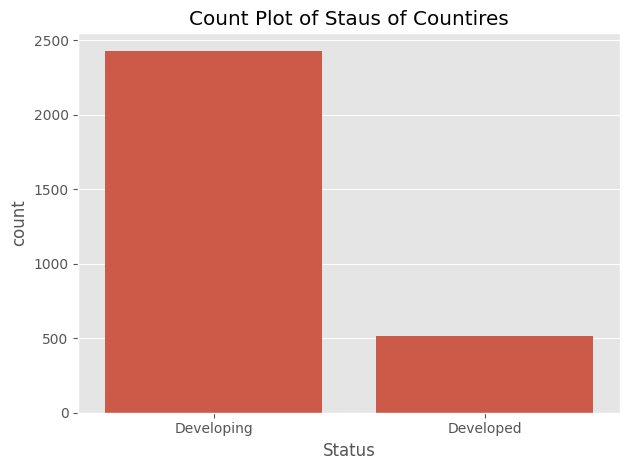

In [ ]:
sns.countplot(x=df['Status'])
plt.title('Count Plot of Staus of Countires')
plt.tight_layout()
plt.show()

In [ ]:
life_expact_status = df.groupby('Status')['Life expectancy '].mean().reset_index()
fig = px.histogram(life_expact_status, x = 'Status', y='Life expectancy ',
                  color='Status')
fig.update_layout(
    title=dict(text='<b>Average Life Expactancy for Status of Country</b>', x=0.5)
)

fig.show()

In [ ]:
# Calculate the average life expectancy and average alcohol consumption for each year
average_data = df.groupby('Year').agg({
    'Life expectancy ': 'mean',
    'Alcohol': 'mean'
}).reset_index()

# Create the interactive plot with dual y-axes
fig = go.Figure()

# Add life expectancy trace
fig.add_trace(go.Scatter(x=average_data['Year'], y=average_data['Life expectancy '],
                         mode='lines+markers', name='Life Expectancy',
                         yaxis='y1'))

# Add alcohol consumption trace
fig.add_trace(go.Scatter(x=average_data['Year'], y=average_data['Alcohol'],
                         mode='lines+markers', name='Alcohol Consumption',
                         yaxis='y2'))

# Update layout for dual y-axes
fig.update_layout(
    title='Life Expectancy and Alcohol Consumption over the Years',
    xaxis=dict(title='Year'),
    yaxis=dict(title='Life Expectancy (years)', side='left'),
    yaxis2=dict(title='Alcohol Consumption (liters)', side='right', overlaying='y'),
    template='plotly_dark'
)

# Show the plot
fig.show()

In [ ]:
fig = px.bar(df.groupby('Status', as_index=False).agg({'Alcohol':'mean'}), y='Alcohol', x='Status',
                 title='Average Alcohol consumption of Developing and Developed Countries',
                 labels={'Alcohol':'Alcohol Consumption (liters per capita)', 'Life expectancy':'Life Expectancy (years)'},
                 template='plotly_dark')

# Show the plot
fig.show()

In [ ]:
df.head(2)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,30.303948,0.01,71.279624,65.0,2419.59224,...,82.550188,8.16,65.0,0.1,584.259210,1.275338e+07,4.839704,4.870317,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,30.303948,0.01,73.523582,62.0,492.00000,...,58.000000,8.18,62.0,0.1,612.696514,3.275820e+05,4.839704,4.870317,0.476,10.0


In [ ]:
aggregated_data = df.groupby('Schooling')['Life expectancy '].mean().reset_index()

# Create the interactive line plot
fig = px.line(aggregated_data, x='Schooling', y='Life expectancy ',
              title='Average Life Expectancy vs Years of Schooling',
              labels={'Schooling':'Years of Schooling', 'Life expectancy':'Life Expectancy (years)'},
              template='plotly_dark')

# Show the plot
fig.show()

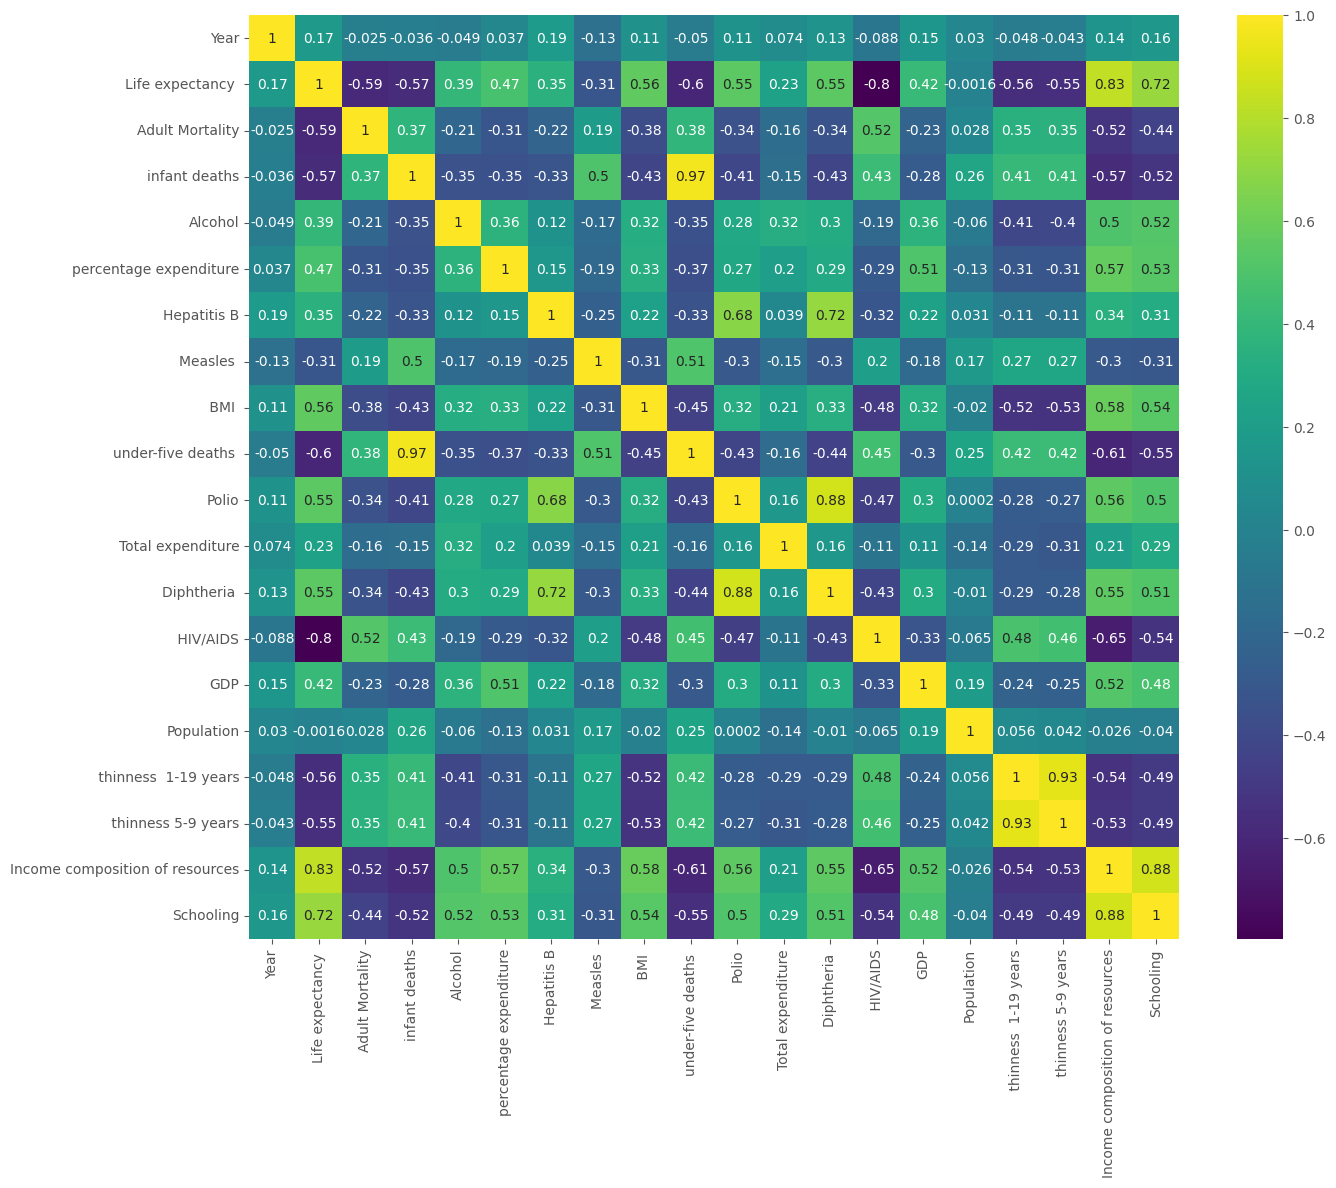

In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(df[numerical_cols].corr(), cmap='viridis', annot=True) # Corrected the variable name to 'numerical_cols'
plt.show()

DATA PRE PROCESSING

In [ ]:
le = LabelEncoder()
cat_cols = df.select_dtypes(include = 'object').columns
for cols in cat_cols:
    df[cols] = le.fit_transform(df[cols])

In [ ]:
x =  df.drop(columns='Life expectancy ')
y = df['Life expectancy ']

In [ ]:
scaler = StandardScaler()
cols_to_scale = x.drop(columns='Status').columns

# for cols in cols_to_scale:
x[cols_to_scale] = scaler.fit_transform(x[cols_to_scale])

In [ ]:
x.head()

,Country,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,-1.691042,1.621762,1,1.057680,1.351263,-1.176057,-0.553370,-2.391880,2.071994,-0.964715,...,-0.539321,1.094972,-2.254819,-0.634808,-0.926044,0.963765,0.145396,0.148652,-1.144346,-0.726426
1,-1.691042,1.404986,1,1.134943,1.351263,-1.176057,-0.545858,-2.717043,-0.023881,-0.989810,...,-2.792128,1.104265,-2.541909,-0.634808,-0.918525,-0.939099,0.145396,0.148652,-1.163816,-0.761514
2,-1.691042,1.188210,1,1.105970,1.351263,-1.176057,-0.546877,-2.500268,-0.091294,-1.014905,...,-2.425075,1.081034,-2.350516,-0.634808,-0.913488,0.963765,0.145396,0.148652,-1.202757,-0.796602
3,-1.691042,0.971434,1,1.144601,1.351263,-1.176057,-0.530255,-2.175105,2.071994,-1.040000,...,-1.966258,1.262237,-2.063426,-0.634808,-0.903384,-0.423119,0.145396,0.148652,-1.248189,-0.831691
4,-1.691042,0.754658,1,1.173575,1.351263,-1.176057,-0.768242,-2.066717,2.071994,-1.060076,...,-1.874495,0.960231,-1.967730,-0.634808,-1.063727,-0.533127,0.145396,0.148652,-1.306601,-0.936956


MODEL BUILD

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 30)

In [ ]:
print(f"Shape of X_train is: {x_train.shape}")
print(f"Shape of Y_train is: {y_train.shape}\n")
print(f"Shape of X_test is: {x_test.shape}")
print(f"Shape of Y_test is: {y_test.shape}")

Shape of X_train is: (2350, 21)
Shape of Y_train is: (2350,)

Shape of X_test is: (588, 21)
Shape of Y_test is: (588,)


In [ ]:
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'Extra Trees Regressor': ExtraTreesRegressor(random_state=42),
    'GradientBoost Regressor': GradientBoostingRegressor(random_state=42),
    'XGB Regressor': XGBRegressor()
}

# list to store results
results = []

# Train and evaluate each model
for model_name, model in models.items():
    # Train the model
    model.fit(x_train, y_train)

    # Make predictions
    y_pred = model.predict(x_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # removed squared=False and used np.sqrt to calculate rmse
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    # Store results in list
    results.append({'Model': model_name, 'RMSE': rmse, 'R2 Score': r2, 'MAE' : mae })

results_df = pd.DataFrame(results)

In [ ]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# list to store results
results = []

# Train and evaluate each model
for model_name, model in models.items():
    # Train the model
    model.fit(x_train, y_train)

    # Make predictions
    y_pred = model.predict(x_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    # Store results in list
    results.append({'Model': model_name, 'RMSE': rmse, 'R2 Score': r2, 'MAE' : mae, 'MAPE': mape})

results_df = pd.DataFrame(results)
results_df=results_df.sort_values("R2 Score", ascending = False)
results_df


,Model,RMSE,R2 Score,MAE,MAPE
3,XGB Regressor,1.981816,0.959251,1.244384,1.880425
1,Extra Trees Regressor,1.993149,0.958783,1.111851,1.724752
0,Random Forest,2.033441,0.957100,1.242128,1.890747
2,GradientBoost Regressor,2.417593,0.939360,1.687858,2.559636


In [ ]:
from sklearn.model_selection import cross_val_score, KFold

best_model = XGBRegressor()

kf = KFold(n_splits=20, shuffle=True, random_state=42)

cross_val = cross_val_score(best_model, x, y, cv= kf, scoring='r2')
cross_val

array([0.96870258, 0.96957899, 0.97628745, 0.95949212, 0.9747437 ,
       0.94493638, 0.96378644, 0.96325678, 0.98002501, 0.96468556,
       0.94654413, 0.96222682, 0.95963476, 0.95581229, 0.94591112,
       0.95876267, 0.96622263, 0.96710515, 0.96993108, 0.95223263])

In [ ]:
cross_val.mean()

np.float64(0.9624939137696394)

In [ ]:
cross_val.std()

np.float64(0.009624725292876094)

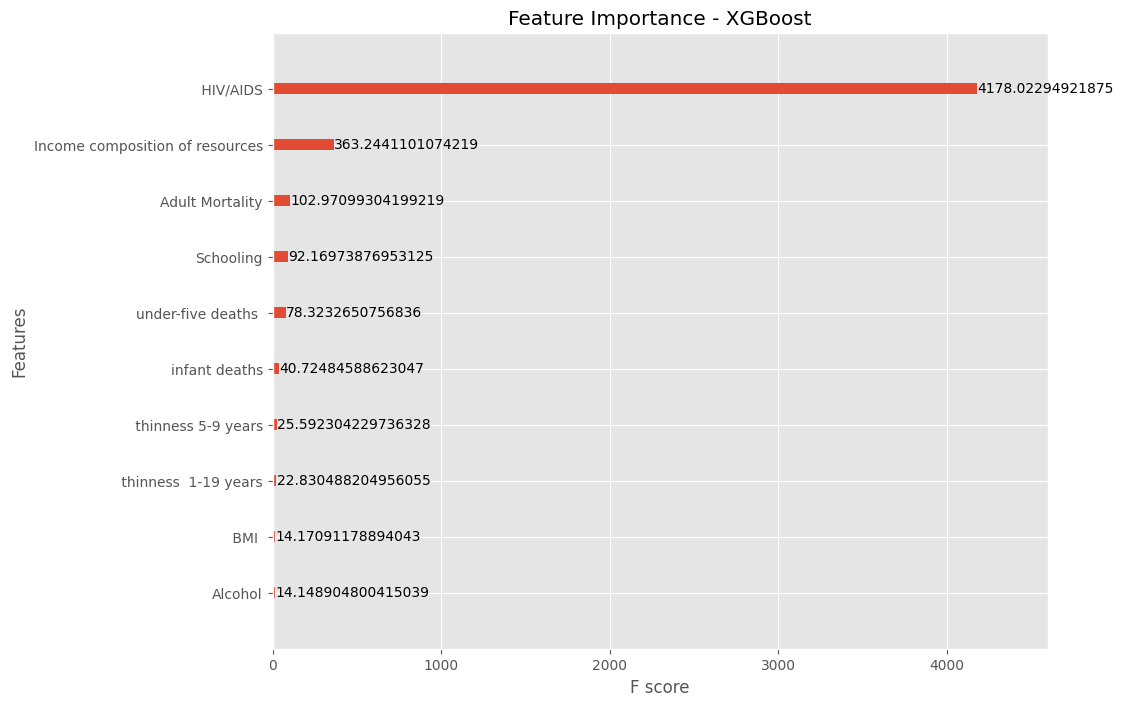

                           Feature  Importance
0                         HIV/AIDS    0.832236
1  Income composition of resources    0.072356
2                  Adult Mortality    0.020511
3                        Schooling    0.018360
4               under-five deaths     0.015602
5                    infant deaths    0.008112
6               thinness 5-9 years    0.005098
7             thinness  1-19 years    0.004548
8                             BMI     0.002823
9                          Alcohol    0.002818


In [ ]:
from xgboost import plot_importance

best_model.fit(x, y)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(best_model, ax=ax, importance_type='gain', max_num_features=10)
plt.title('Feature Importance - XGBoost')
plt.show()

# If you want to see the importance as a table
importance_scores = best_model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print(feature_importance.head(10))

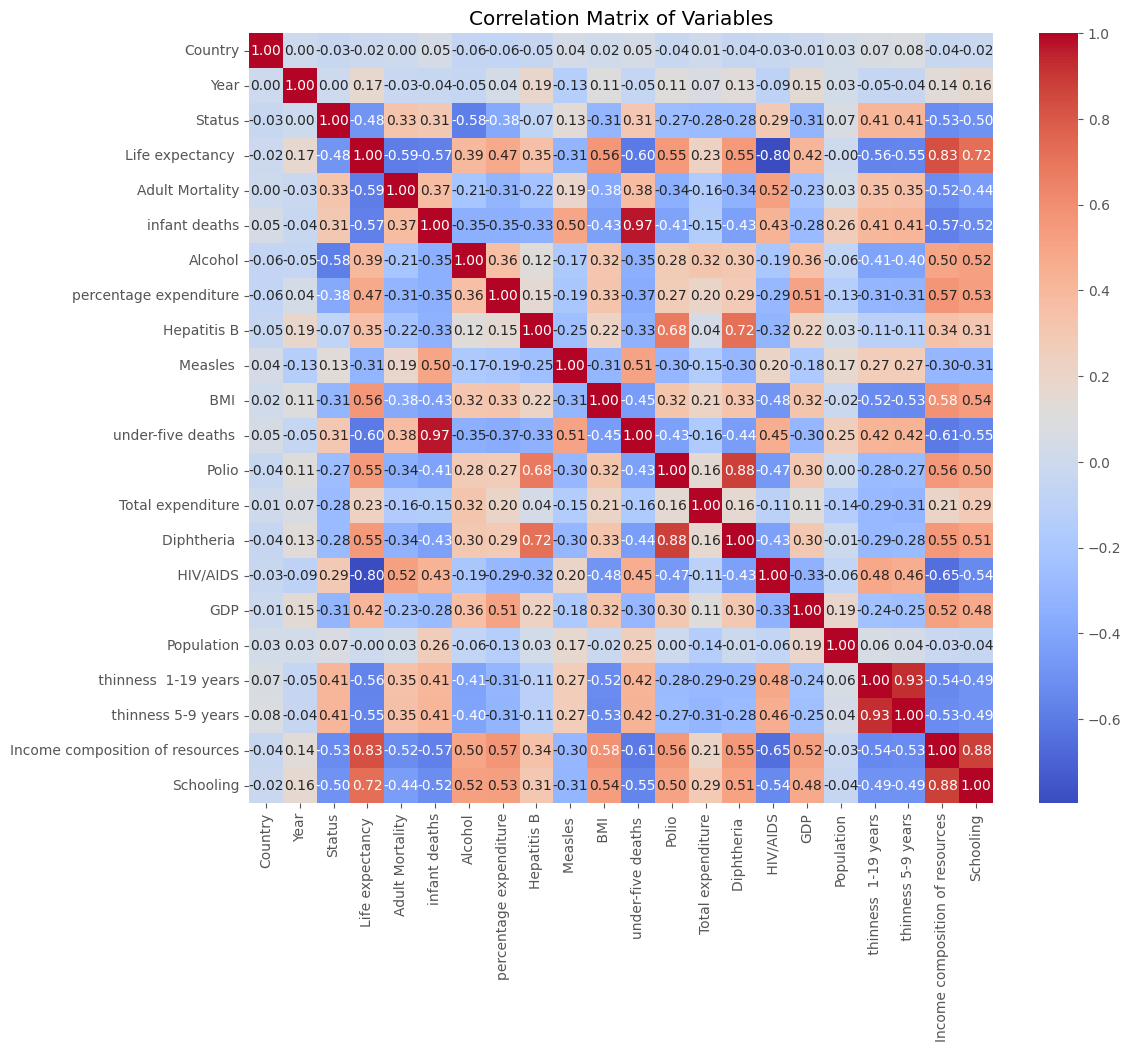

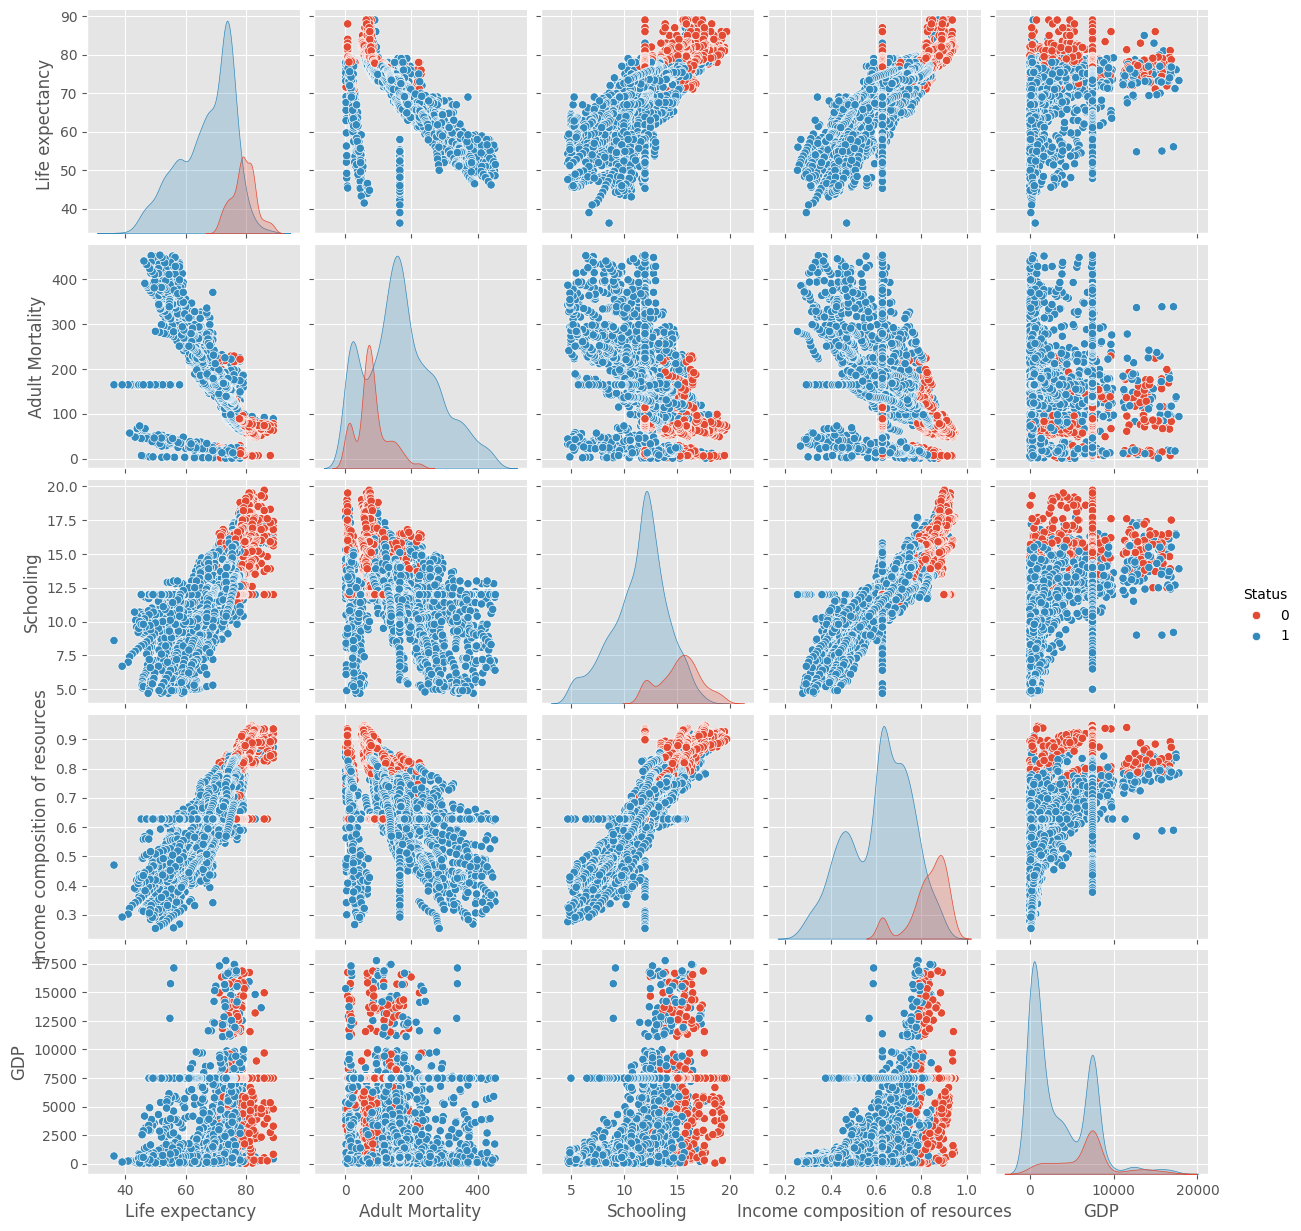

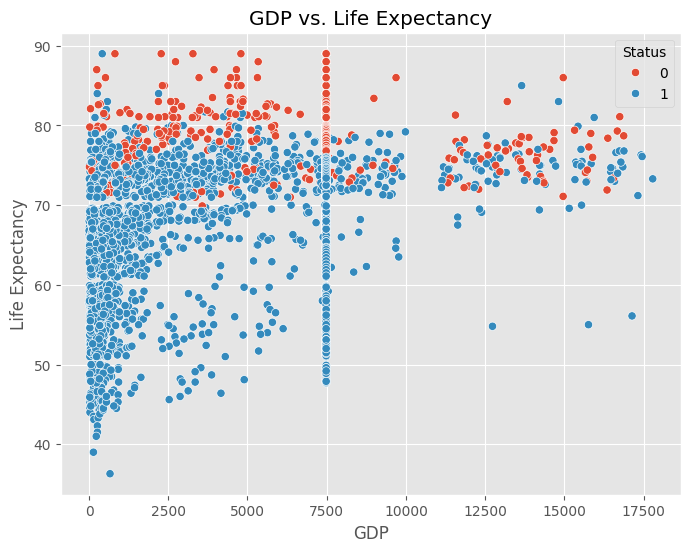

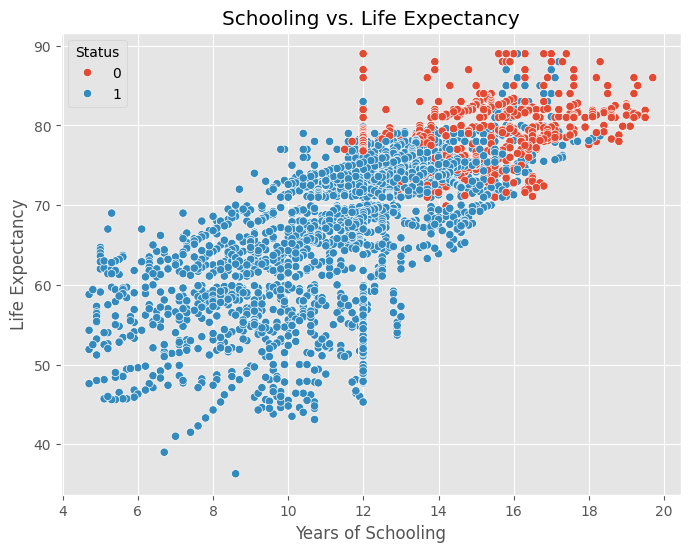

Pearson correlation between GDP and Life Expectancy: 0.42
P-value: 0.000
There is a statistically significant correlation between GDP and Life Expectancy.


In [ ]:

import matplotlib.pyplot as plt

correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Variables')
plt.show()

# Pairplot for visualization of relationships between variables
sns.pairplot(df, vars=['Life expectancy ', 'Adult Mortality', 'Schooling', 'Income composition of resources', 'GDP'], hue='Status')
plt.show()

# Scatter plots for specific relationships
plt.figure(figsize=(8, 6))
sns.scatterplot(x='GDP', y='Life expectancy ', data=df, hue='Status')
plt.title('GDP vs. Life Expectancy')
plt.xlabel('GDP')
plt.ylabel('Life Expectancy')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Schooling', y='Life expectancy ', data=df, hue='Status')
plt.title('Schooling vs. Life Expectancy')
plt.xlabel('Years of Schooling')
plt.ylabel('Life Expectancy')
plt.show()


# Statistical Tests (Example: Pearson correlation)
from scipy.stats import pearsonr

# Calculate Pearson correlation coefficient and p-value for GDP and Life Expectancy
correlation_coefficient, p_value = pearsonr(df['GDP'], df['Life expectancy '])
print(f"Pearson correlation between GDP and Life Expectancy: {correlation_coefficient:.2f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
if p_value < 0.05:
    print("There is a statistically significant correlation between GDP and Life Expectancy.")
else:
    print("There is no statistically significant correlation between GDP and Life Expectancy.")


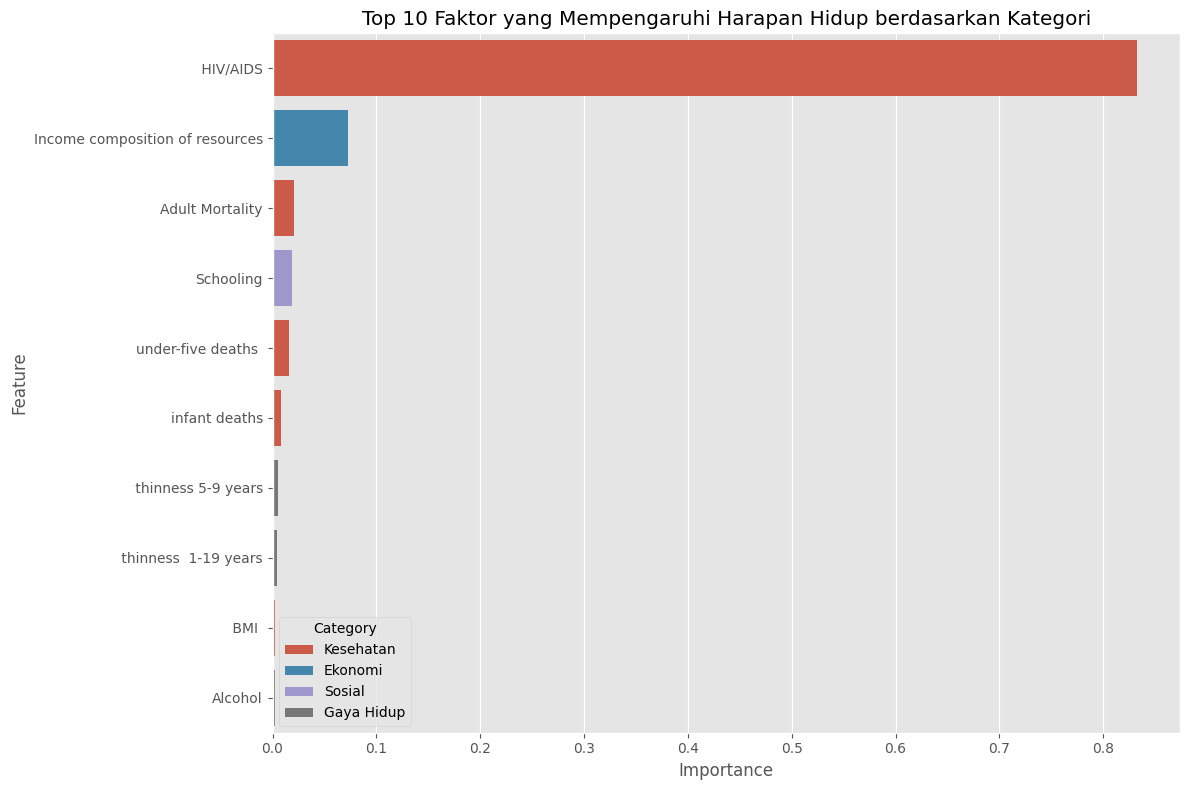

In [ ]:
# 1. Analisis fitur penting berdasarkan kategori
# Mengelompokkan fitur berdasarkan kategori
feature_categories = {
    'Ekonomi': ['GDP', 'Income composition of resources', 'percentage expenditure', 'Total expenditure'],
    'Kesehatan': ['Adult Mortality', 'infant deaths', 'under-five deaths ', ' BMI ', 'Polio', 'Diphtheria ', ' HIV/AIDS'],
    'Sosial': ['Schooling', 'Status'],
    'Gaya Hidup': ['Alcohol', ' thinness  1-19 years', ' thinness 5-9 years']
}

# Fungsi untuk mendapatkan kategori dari fitur
def get_category(feature):
    for category, features in feature_categories.items():
        if feature in features:
            return category
    return 'Lainnya'

# Tambahkan kategori ke DataFrame feature importance
feature_importance['Category'] = feature_importance['Feature'].apply(get_category)

# Plot fitur penting berdasarkan kategori
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Category', data=feature_importance.head(10))
plt.title('Top 10 Faktor yang Mempengaruhi Harapan Hidup berdasarkan Kategori')
plt.tight_layout()
plt.show()

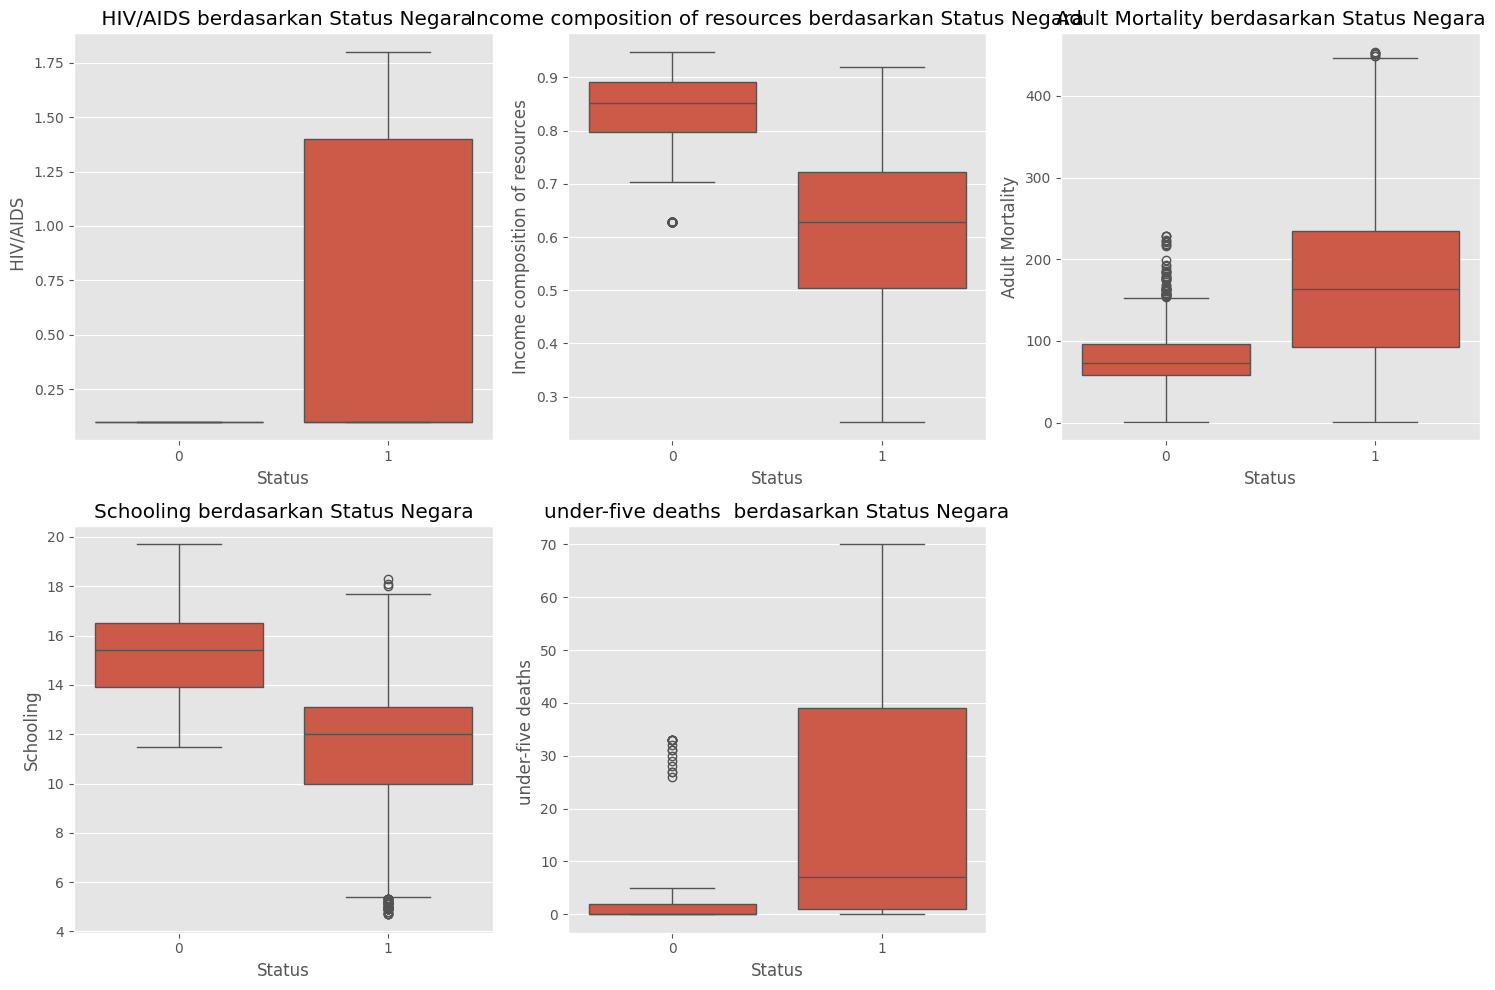

In [ ]:
# 2. Analisis pengaruh fitur penting terhadap negara dengan harapan hidup rendah
# Identifikasi negara dengan harapan hidup rendah
low_life_exp_countries = df[df['Life expectancy '] < df['Life expectancy '].quantile(0.25)]
top_5_features = feature_importance['Feature'].head(5).tolist()

# Bandingkan nilai fitur penting untuk negara dengan harapan hidup rendah vs tinggi
plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_5_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='Status', y=feature, data=df)
    plt.title(f'{feature} berdasarkan Status Negara')
plt.tight_layout()
plt.show()

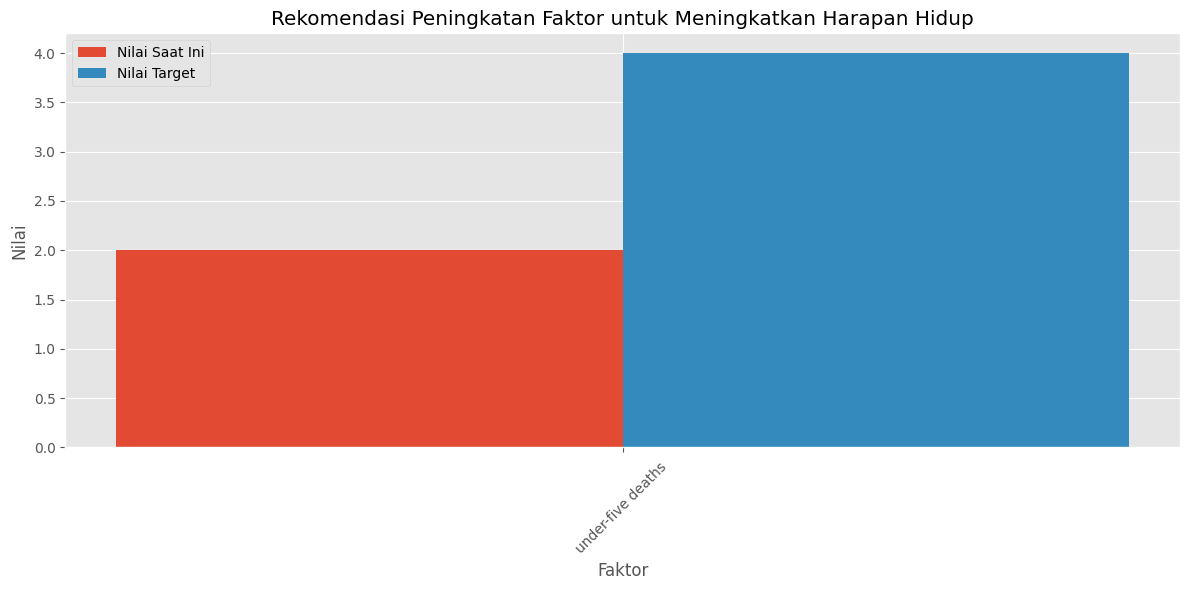

In [ ]:
# 3. Rekomendasi berdasarkan fitur penting
# Membuat fungsi untuk menghasilkan rekomendasi
def generate_recommendations(country_data, feature_importance):
    recommendations = {}
    top_features = feature_importance['Feature'].head(5).tolist()

    for feature in top_features:
        country_value = country_data[feature].values[0]
        median_value = df[feature].median()

        if country_value < median_value:
            gap = median_value - country_value
            recommendations[feature] = {
                'current_value': country_value,
                'target_value': median_value,
                'gap': gap,
                'importance_score': feature_importance[feature_importance['Feature'] == feature]['Importance'].values[0]
            }

    return recommendations

# Contoh rekomendasi untuk negara dengan harapan hidup rendah
sample_country = df[df['Country'] == 21].iloc[0:1]  # Pilih satu negara sebagai contoh
country_recommendations = generate_recommendations(sample_country, feature_importance)

# Visualisasi rekomendasi untuk sample country
if country_recommendations:
    features = list(country_recommendations.keys())
    current_values = [rec['current_value'] for rec in country_recommendations.values()]
    target_values = [rec['target_value'] for rec in country_recommendations.values()]

    plt.figure(figsize=(12, 6))
    x = np.arange(len(features))
    width = 0.35

    plt.bar(x - width/2, current_values, width, label='Nilai Saat Ini')
    plt.bar(x + width/2, target_values, width, label='Nilai Target')

    plt.xlabel('Faktor')
    plt.ylabel('Nilai')
    plt.title('Rekomendasi Peningkatan Faktor untuk Meningkatkan Harapan Hidup')
    plt.xticks(x, features, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
print(df['Country'].unique())

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  44  27  28  29  30  31  32  33  34
  35  36  37  38  39  40  41  42  43  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192]


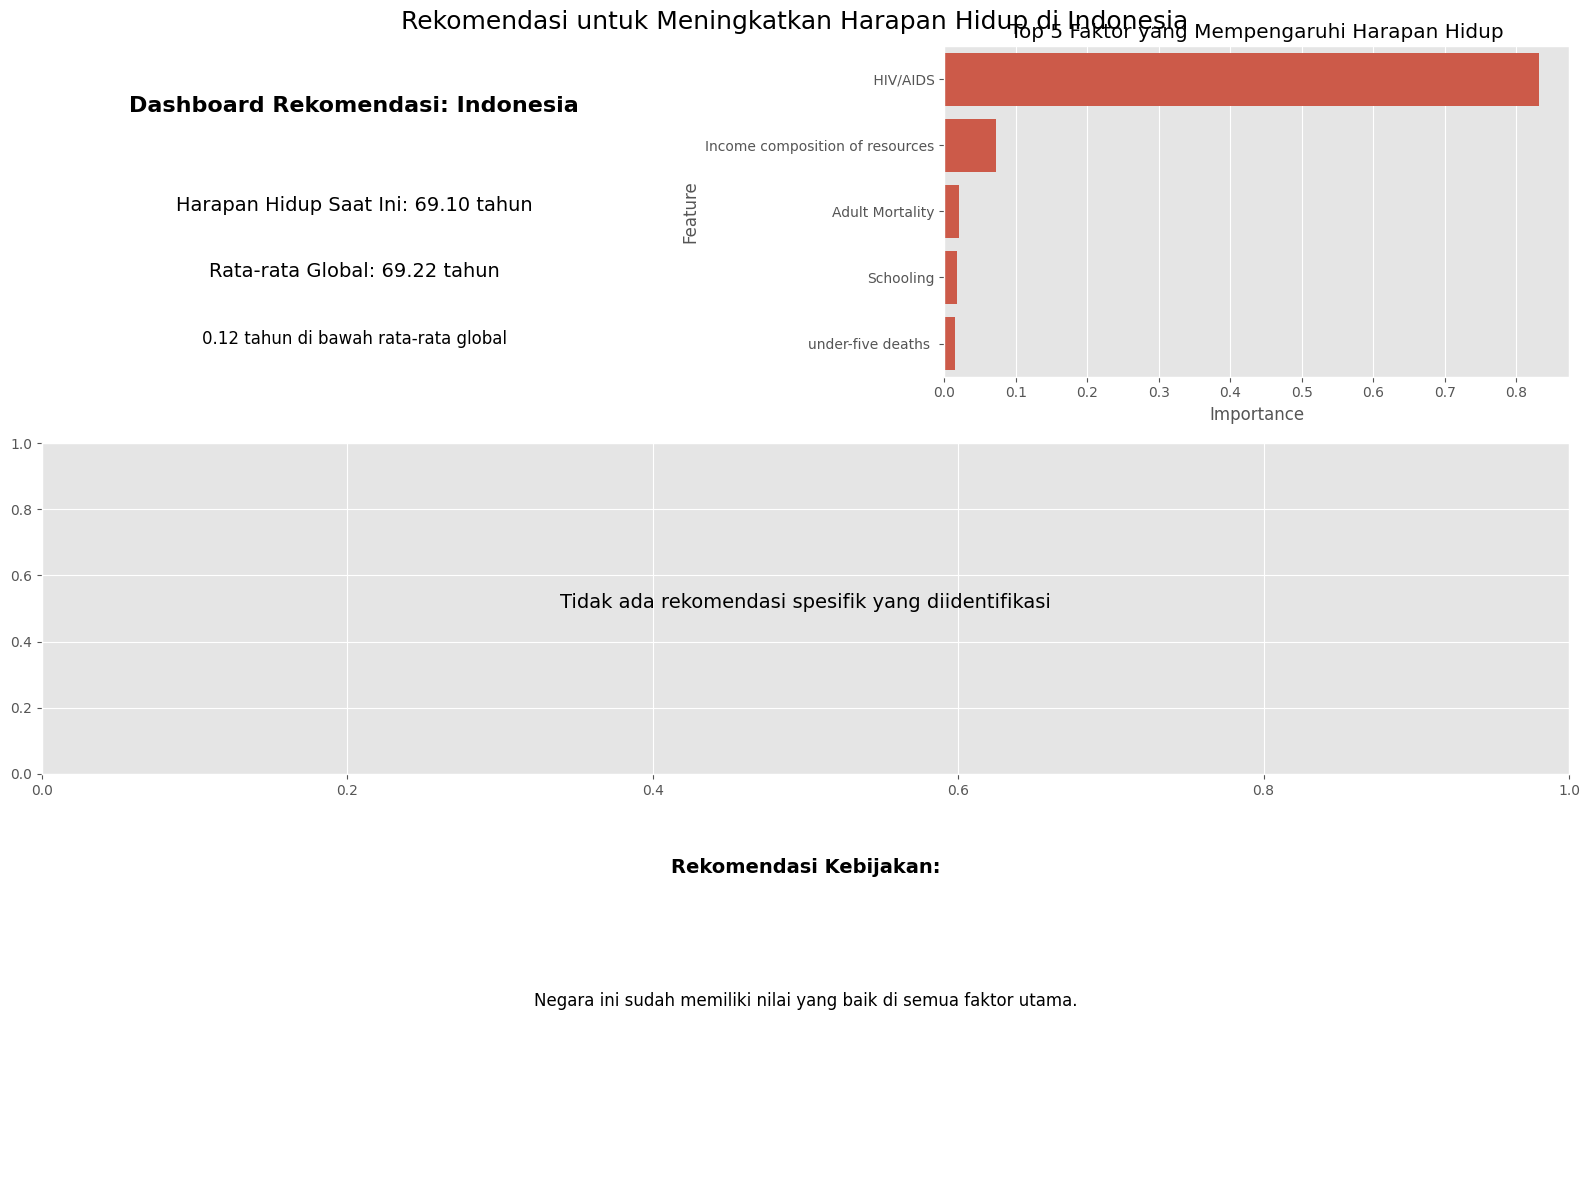

In [ ]:
# 4. Dashboard Rekomendasi Sederhana
import matplotlib.gridspec as gridspec

country_mapping = {
    0: 'Afghanistan',
    1: 'Albania',
    2: 'Algeria',
    3: 'Angola',
    4: 'Antigua and Barbuda',
    5: 'Argentina',
    6: 'Armenia',
    7: 'Australia',
    8: 'Austria',
    9: 'Azerbaijan',
    10: 'Bahamas',
    11: 'Bahrain',
    12: 'Bangladesh',
    13: 'Barbados',
    14: 'Belarus',
    15: 'Belgium',
    16: 'Belize',
    17: 'Benin',
    18: 'Bhutan',
    19: 'Bolivia (Plurinational State of)',
    20: 'Bosnia and Herzegovina',
    21: 'Botswana',
    22: 'Brazil',
    23: 'Brunei Darussalam',
    24: 'Bulgaria',
    25: 'Burkina Faso',
    26: 'Burundi',
    27: "Côte d'Ivoire",
    28: 'Cabo Verde',
    29: 'Cambodia',
    30: 'Cameroon',
    31: 'Canada',
    32: 'Central African Republic',
    33: 'Chad',
    34: 'Chile',
    35: 'China',
    36: 'Colombia',
    37: 'Comoros',
    38: 'Congo',
    39: 'Cook Islands',
    40: 'Costa Rica',
    41: 'Croatia',
    42: 'Cuba',
    43: 'Cyprus',
    44: 'Czechia',
    45: "Democratic People's Republic of Korea",
    46: 'Democratic Republic of the Congo',
    47: 'Denmark',
    48: 'Djibouti',
    49: 'Dominica',
    50: 'Dominican Republic',
    51: 'Ecuador',
    52: 'Egypt',
    53: 'El Salvador',
    54: 'Equatorial Guinea',
    55: 'Eritrea',
    56: 'Estonia',
    57: 'Ethiopia',
    58: 'Fiji',
    59: 'Finland',
    60: 'France',
    61: 'Gabon',
    62: 'Gambia',
    63: 'Georgia',
    64: 'Germany',
    65: 'Ghana',
    66: 'Greece',
    67: 'Grenada',
    68: 'Guatemala',
    69: 'Guinea',
    70: 'Guinea-Bissau',
    71: 'Guyana',
    72: 'Haiti',
    73: 'Honduras',
    74: 'Hungary',
    75: 'Iceland',
    76: 'India',
    77: 'Indonesia',
    78: 'Iran (Islamic Republic of)',
    79: 'Iraq',
    80: 'Ireland',
    81: 'Israel',
    82: 'Italy',
    83: 'Jamaica',
    84: 'Japan',
    85: 'Jordan',
    86: 'Kazakhstan',
    87: 'Kenya',
    88: 'Kiribati',
    89: 'Kuwait',
    90: 'Kyrgyzstan',
    91: "Lao People's Democratic Republic",
    92: 'Latvia',
    93: 'Lebanon',
    94: 'Lesotho',
    95: 'Liberia',
    96: 'Libya',
    97: 'Lithuania',
    98: 'Luxembourg',
    99: 'Madagascar',
    100: 'Malawi',
    101: 'Malaysia',
    102: 'Maldives',
    103: 'Mali',
    104: 'Malta',
    105: 'Marshall Islands',
    106: 'Mauritania',
    107: 'Mauritius',
    108: 'Mexico',
    109: 'Micronesia (Federated States of)',
    110: 'Monaco',
    111: 'Mongolia',
    112: 'Montenegro',
    113: 'Morocco',
    114: 'Mozambique',
    115: 'Myanmar',
    116: 'Namibia',
    117: 'Nauru',
    118: 'Nepal',
    119: 'Netherlands',
    120: 'New Zealand',
    121: 'Nicaragua',
    122: 'Niger',
    123: 'Nigeria',
    124: 'Niue',
    125: 'Norway',
    126: 'Oman',
    127: 'Pakistan',
    128: 'Palau',
    129: 'Panama',
    130: 'Papua New Guinea',
    131: 'Paraguay',
    132: 'Peru',
    133: 'Philippines',
    134: 'Poland',
    135: 'Portugal',
    136: 'Qatar',
    137: 'Republic of Korea',
    138: 'Republic of Moldova',
    139: 'Romania',
    140: 'Russian Federation',
    141: 'Rwanda',
    142: 'Saint Kitts and Nevis',
    143: 'Saint Lucia',
    144: 'Saint Vincent and the Grenadines',
    145: 'Samoa',
    146: 'San Marino',
    147: 'Sao Tome and Principe',
    148: 'Saudi Arabia',
    149: 'Senegal',
    150: 'Serbia',
    151: 'Seychelles',
    152: 'Sierra Leone',
    153: 'Singapore',
    154: 'Slovakia',
    155: 'Slovenia',
    156: 'Solomon Islands',
    157: 'Somalia',
    158: 'South Africa',
    159: 'South Sudan',
    160: 'Spain',
    161: 'Sri Lanka',
    162: 'Sudan',
    163: 'Suriname',
    164: 'Swaziland',
    165: 'Sweden',
    166: 'Switzerland',
    167: 'Syrian Arab Republic',
    168: 'Tajikistan',
    169: 'Thailand',
    170: 'The former Yugoslav republic of Macedonia',
    171: 'Timor-Leste',
    172: 'Togo',
    173: 'Tonga',
    174: 'Trinidad and Tobago',
    175: 'Tunisia',
    176: 'Turkey',
    177: 'Turkmenistan',
    178: 'Tuvalu',
    179: 'Uganda',
    180: 'Ukraine',
    181: 'United Arab Emirates',
    182: 'United Kingdom of Great Britain and Northern Ireland',
    183: 'United Republic of Tanzania',
    184: 'United States of America',
    185: 'Uruguay',
    186: 'Uzbekistan',
    187: 'Vanuatu',
    188: 'Venezuela (Bolivarian Republic of)',
    189: 'Viet Nam',
    190: 'Yemen',
    191: 'Zambia',
    192: 'Zimbabwe'
}

# Fungsi untuk mendapatkan nama negara berdasarkan kode
def get_country_name(code):
    return country_mapping.get(code, f"Unknown Country (Code: {code})")

def create_recommendation_dashboard(country_code):
    country_data = df[df['Country'] == country_code].iloc[0:1]
    country_name = get_country_name(country_code)
    country_life_exp = country_data['Life expectancy '].values[0]
    global_avg_life_exp = df['Life expectancy '].mean()
    recommendations = generate_recommendations(country_data, feature_importance)

    fig = plt.figure(figsize=(16, 12))
    gs = gridspec.GridSpec(3, 2, figure=fig)

    # 1. Informasi Dasar Negara
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.axis('off')
    ax1.text(0.5, 0.8, f"Dashboard Rekomendasi: {country_name}", ha='center', fontsize=16, fontweight='bold')
    ax1.text(0.5, 0.5, f"Harapan Hidup Saat Ini: {country_life_exp:.2f} tahun", ha='center', fontsize=14)
    ax1.text(0.5, 0.3, f"Rata-rata Global: {global_avg_life_exp:.2f} tahun", ha='center', fontsize=14)
    difference = country_life_exp - global_avg_life_exp
    status = "di atas" if difference > 0 else "di bawah"
    ax1.text(0.5, 0.1, f"{abs(difference):.2f} tahun {status} rata-rata global", ha='center', fontsize=12)

    # 2. Top 5 Faktor Penting
    ax2 = fig.add_subplot(gs[0, 1])
    top_features = feature_importance.head(5)
    sns.barplot(x='Importance', y='Feature', data=top_features, ax=ax2)
    ax2.set_title('Top 5 Faktor yang Mempengaruhi Harapan Hidup')

    # 3. Perbandingan dengan Rata-rata
    ax3 = fig.add_subplot(gs[1, :])
    if recommendations:
        features = list(recommendations.keys())
        current_values = [rec['current_value'] for rec in recommendations.values()]
        target_values = [rec['target_value'] for rec in recommendations.values()]

        x = np.arange(len(features))
        width = 0.35

        ax3.bar(x - width/2, current_values, width, label='Nilai Saat Ini')
        ax3.bar(x + width/2, target_values, width, label='Nilai Target')

        ax3.set_xlabel('Faktor')
        ax3.set_ylabel('Nilai')
        ax3.set_title('Area yang Perlu Ditingkatkan')
        ax3.set_xticks(x)
        ax3.set_xticklabels(features, rotation=45)
        ax3.legend()
    else:
        ax3.text(0.5, 0.5, "Tidak ada rekomendasi spesifik yang diidentifikasi", ha='center', fontsize=14)

    # 4. Rekomendasi Tertulis
    ax4 = fig.add_subplot(gs[2, :])
    ax4.axis('off')
    ax4.text(0.5, 0.9, "Rekomendasi Kebijakan:", ha='center', fontsize=14, fontweight='bold')

    y_pos = 0.8
    if recommendations:
        for i, (feature, rec) in enumerate(recommendations.items()):
            ax4.text(0.5, y_pos - i*0.1,
                    f"{i+1}. Tingkatkan {feature} dari {rec['current_value']:.2f} menjadi {rec['target_value']:.2f} "
                    f"(potensi peningkatan harapan hidup: {rec['importance_score']*rec['gap']/sum([r['importance_score']*r['gap'] for r in recommendations.values()]):.2f} tahun)",
                    ha='center', fontsize=12)
    else:
        ax4.text(0.5, 0.5, "Negara ini sudah memiliki nilai yang baik di semua faktor utama.", ha='center', fontsize=12)

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.suptitle(f"Rekomendasi untuk Meningkatkan Harapan Hidup di {country_name}", fontsize=18, y=0.98)
    plt.show()

# Contoh penggunaan dashboard
create_recommendation_dashboard(77)  # Ganti dengan kode negara yang ingin dianalisis